# 04. GPT-2 감정분석 (시퀀스 분류)

**모델**: `gpt2` (124M, 가장 작은 GPT-2)  

## GPT-2를 분류에 쓰는 이유와 도전 과제

GPT-2는 본래 **생성 모델**(다음 단어 예측)이지만, 마지막 토큰의 hidden state 위에 분류 헤드를 붙이면 분류기로도 쓸 수 있다.

### 0. Google Drive 마운트 및 경로 설정

In [1]:
# Google Drive 마운트
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/sentiment_analysis'
    IN_COLAB = True
except ImportError:
    # 로컬 환경에서 실행할 경우: 현재 디렉토리 기준
    PROJECT_DIR = '.'
    IN_COLAB = False
    print('로컬 환경에서 실행 중')

# 하위 폴더 정의
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# utils.py import 경로 추가
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print(f'프로젝트 경로: {PROJECT_DIR}')
print(f'데이터 경로 : {DATA_DIR}')
print(f'결과 경로  : {RESULTS_DIR}')

Mounted at /content/drive
프로젝트 경로: /content/drive/MyDrive/sentiment_analysis
데이터 경로 : /content/drive/MyDrive/sentiment_analysis/data
결과 경로  : /content/drive/MyDrive/sentiment_analysis/results


### 1. 환경 설정

In [2]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [4]:
import time, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from transformers import (
    GPT2Tokenizer, GPT2ForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score

from utils import (load_data, evaluate_model, plot_confusion_matrix,
                   show_misclassified, LABEL_NAMES)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print(f'CUDA: {torch.cuda.is_available()}')

CUDA: True


### 2. 데이터 로드

In [5]:
X_train_text, y_train, X_test_text, y_test = load_data(
    train_path=os.path.join(DATA_DIR, 'train_clean.csv'),
    test_path=os.path.join(DATA_DIR, 'test_clean.csv'),
    text_col='text_transformer'
)

ds_train = Dataset.from_dict({'text': list(X_train_text), 'labels': list(y_train.astype(int))})
ds_test  = Dataset.from_dict({'text': list(X_test_text),  'labels': list(y_test.astype(int))})

split = ds_train.train_test_split(test_size=0.1, seed=SEED)
ds_train, ds_val = split['train'], split['test']

print(f'Train: {len(ds_train):,} / Val: {len(ds_val):,} / Test: {len(ds_test):,}')

Train: 24,729 / Val: 2,748 / Test: 3,534


### 3. 토크나이저 설정

GPT-2는 기본적으로 **pad token이 없다** (생성 모델은 패딩이 필요 없으니까). 분류용으로 쓰려면 직접 추가해야 함.

In [6]:
MODEL_NAME = 'gpt2'
MAX_LEN = 64

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token   # ← 중요: pad token = eos token

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

ds_train = ds_train.map(tokenize_fn, batched=True)
ds_val   = ds_val.map(tokenize_fn, batched=True)
ds_test  = ds_test.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print('토큰화 완료')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/24729 [00:00<?, ? examples/s]

Map:   0%|          | 0/2748 [00:00<?, ? examples/s]

Map:   0%|          | 0/3534 [00:00<?, ? examples/s]

토큰화 완료


In [7]:
model = GPT2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: 'negative', 1: 'neutral', 2: 'positive'},
    label2id={'negative': 0, 'neutral': 1, 'positive': 2},
)
model.config.pad_token_id = tokenizer.pad_token_id   # ← 동기화 필수

print(f'파라미터 수: {model.num_parameters():,}')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


파라미터 수: 124,442,112


### 4. 학습

In [9]:
def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    return {
        'accuracy': accuracy_score(eval_pred.label_ids, preds),
        'f1_macro': f1_score(eval_pred.label_ids, preds, average='macro'),
    }

training_args = TrainingArguments(
    output_dir=os.path.join(RESULTS_DIR, 'gpt2_output'),
    num_train_epochs=3,
    per_device_train_batch_size=16,    # GPT-2는 메모리 더 먹음
    per_device_eval_batch_size=32,
    learning_rate=1e-5,                 # BERT(2e-5)보다 작게
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=100,
    report_to='none',
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=ds_train, eval_dataset=ds_val,
    processing_class=tokenizer, data_collator=data_collator,
    compute_metrics=compute_metrics,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [10]:
t0 = time.time()
trainer.train()
gpt_time = time.time() - t0
print(f'\n⏱ GPT-2 학습 시간: {gpt_time:.1f}s ({gpt_time/60:.1f}분)')

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.602602,0.591308,0.748180,0.751322
2,0.519237,0.547555,0.774381,0.778258
3,0.499100,0.547908,0.777656,0.781568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


⏱ GPT-2 학습 시간: 453.0s (7.6분)


### 5. 평가

In [11]:
preds_output = trainer.predict(ds_test)
y_pred_gpt = np.argmax(preds_output.predictions, axis=1)

result_gpt = evaluate_model(y_test, y_pred_gpt, 'GPT-2')
result_gpt['train_time_sec'] = gpt_time
result_gpt['num_params'] = int(model.num_parameters())


📊 GPT-2 평가 결과
  Accuracy        : 0.7906
  F1 (macro)      : 0.7940
  F1 (weighted)   : 0.7903
  Precision macro : 0.7920
  Recall macro    : 0.7972

--- Classification Report ---
              precision    recall  f1-score   support

    negative     0.7599    0.8252    0.7912      1001
     neutral     0.7734    0.7350    0.7537      1430
    positive     0.8428    0.8314    0.8371      1103

    accuracy                         0.7906      3534
   macro avg     0.7920    0.7972    0.7940      3534
weighted avg     0.7912    0.7906    0.7903      3534



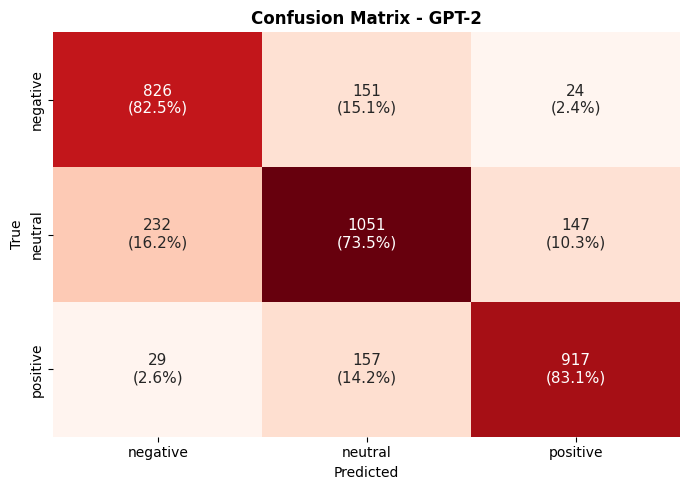

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_confusion_matrix(y_test, y_pred_gpt, 'GPT-2', ax=ax, cmap='Reds')
plt.tight_layout(); plt.show()

In [13]:
show_misclassified(X_test_text, y_test, y_pred_gpt, n=5)


 오분류 사례 (5개, 전체 740개 중)
------------------------------------------------------------
[True: negative | Pred: positive]
  → Just read a book called 'Gamer Girl' and it wasn`t too bad.

[True:  neutral | Pred: positive]
  → Now I like #startrek. Personal feels that #Startrek movie is better than #xmen.

[True: negative | Pred:  neutral]
  → Pulled in all directions and not knowing where to go

[True: negative | Pred:  neutral]
  → waiting for aaron to get into town, and then leave him for work. boo

[True: positive | Pred:  neutral]
  → not sexy with 2 tubes sticking out of my stomach but thanks !



In [14]:
with open(os.path.join(RESULTS_DIR, 'result_gpt.json'), 'w') as f:
    json.dump({k: float(v) if isinstance(v, (int,float,np.floating)) else v
               for k,v in result_gpt.items()}, f, indent=2)

np.savez(os.path.join(RESULTS_DIR, 'preds_gpt.npz'), y_test=y_test, pred_gpt=y_pred_gpt)
print('result_gpt.json, preds_gpt.npz 저장')

result_gpt.json, preds_gpt.npz 저장
